In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('./../tmpsnx71rnm.csv')
data.columns

Index(['Unnamed: 0', 'Rank (Borda)', 'Model', 'Zero-shot',
       'Active Parameters (B)', 'Total Parameters (B)', 'Embedding Dimensions',
       'Max Tokens', 'Mean (Task)', 'Mean (TaskType)', 'Bitext Mining',
       'Classification', 'Clustering', 'Instruction Reranking',
       'Multilabel Classification', 'Pair Classification', 'Reranking',
       'Retrieval', 'STS'],
      dtype='str')

In [3]:
data.drop(columns=['Unnamed: 0', 'Zero-shot','Active Parameters (B)','Classification', 'Clustering', 'Instruction Reranking',
       'Multilabel Classification', 'Pair Classification', 'STS', 'Mean (Task)', 'Mean (TaskType)', 'Bitext Mining'], inplace=True)

In [4]:
data['Model'] = data['Model'].apply(lambda x: x.split('(')[0].strip().replace('[', '').replace(']', ''))

In [5]:
data.isnull().sum()

Rank (Borda)              0
Model                     0
Total Parameters (B)     48
Embedding Dimensions     16
Max Tokens               35
Reranking               237
Retrieval               234
dtype: int64

In [6]:
for col in data.columns:
    data[col] = data[col].fillna('0.00')
    if data[col].dtype == 'object':
        data[col]=data[col].astype(float)


In [7]:
filtered = data[
    (data['Total Parameters (B)'] != 0.00) &
    (data['Total Parameters (B)'] < 0.25)# & (data['Total Parameters (B)'] < 2.0)
]
sorted_data = filtered.sort_values('Total Parameters (B)', ascending=True)


In [8]:
sorted_data= sorted_data.sort_values('Retrieval', ascending=False)

In [9]:
sorted_data.head(10)

,Rank (Borda),Model,Total Parameters (B),Embedding Dimensions,Max Tokens,Reranking,Retrieval
19,19,jina-embeddings-v5-text-nano,0.212,768.0,8192.0,64.63,63.26
82,83,granite-embedding-97m-multilingual-r2,0.097,384.0,8192.0,59.39,60.32
57,58,F2LLM-v2-160M,0.159,640.0,40960.0,60.34,54.08
65,66,multilingual-e5-small,0.118,384.0,512.0,60.43,50.91
68,69,F2LLM-v2-80M,0.080,320.0,40960.0,58.95,50.13
59,60,bilingual-embedding-small,0.118,384.0,512.0,59.31,49.55
83,84,granite-embedding-107m-multilingual,0.107,384.0,512.0,58.48,48.08
113,114,static-similarity-mrl-multilingual-v1,0.108,1024.0,0.0,49.45,41.21
87,88,nomic-embed-text-v1-ablated,0.137,768.0,8192.0,45.04,40.74
98,99,nomic-embed-text-v1-unsupervised,0.137,768.0,8192.0,48.18,40.66


In [10]:
sorted_data.to_csv('./../filtered_sorted_models.csv', index=False)

In [11]:
import os
os.chdir('./..')

In [12]:
from src.utils import log, CustomException
log = log()

1. Based on research I chose bge-base-en-v1.5.
Features:
    - 0.1B parameters 
    - model size is 430MB approx.
    - 512 MAX tokens
    - Retriever effieciency is also good.

In [13]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer('BAAI/bge-base-en-v1.5')
tokenizer = model.tokenizer

/home/vraj/.conda/envs/eu-mdr/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2353.31it/s]
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [14]:
text = "What is the capital of France? The capital of France is Paris. You can also visit the Eiffel Tower in Paris."
token_count = tokenizer.encode(text)
print(f"Number of tokens: {len(token_count)}")

Number of tokens: 28


In [15]:
import sys
import json
try:
    log.info("Loading cleaned EU MDR 2017-745 documents for token length analysis.")
    with open('data/processed/cleaned_eu_mdr_2017-745.json', 'r') as f:
        docs = json.load(f)
    
    structure_prefix = ""
    part_pattern = "\nPART [A-Z] \n"
    simple_pattern = r'\n(\d+)\.\s*\n'
    decimal_pattern = "\n\d+\.\d+\.\s*\n"
    triple = "\n\d+\.\d+\.\d+\.\s*\n"

    for i, doc in enumerate(docs):
        page_content = doc.get('page_content')
        metadata = doc.get('metadata')
        token_length = len(tokenizer.encode(page_content))
      

            
except Exception as e:
    log.exception(f"An error occurred: {e}")
    raise CustomException(e, sys)

2026-07-18 20:13:33,252 53 3204945777 - INFO - Loading cleaned EU MDR 2017-745 documents for token length analysis.
Token indices sequence length is longer than the specified maximum sequence length for this model (11286 > 512). Running this sequence through the model will result in indexing errors


In [16]:
for doc in docs:
    doc.get('page_content', '')

In [17]:
info = docs[148].get('page_content', '')

In [18]:
import re
pattern = r'\n(\d+)\.\s*\n(.+)'
part_pattern = "\nPART [A-Z] \n(.+)"
matches =  re.finditer(part_pattern, docs[147].get('page_content'))

In [19]:
len(tokenizer.encode(docs[147].get('page_content', '')))

4759

In [20]:
patterns = {
    "part"        : r'\nPART [A-Z] \n(.+)',
    "simple"      : r'\n(\d+)\.\s*\n(.+)',
    "decimal"     : r'(?:^|\n)(\d+\.\d+\.)(?!\d)\s+(.+)',   
    "triple"      : r'(?:^|\n)(\d+\.\d+\.\d+\.)\s+(.+)',
    "paren_letter": r'(?:^|\n)\(([a-z])\)\s+(.+)',          
    "paren_num"   : r'(?:^|\n)\((\d+)\)\s+(.+)',  
    "bullet"      : r'(?:^|\n)(—)\s+(.+)',          
}

marker_patterns = {"pattern_annex" : "^(ANNEX [IVX]+) \n(.+)", "pattern_chapter" : "^(CHAPTER [IVX]+) \n(.+)", "pattern_section" : "^(SECTION [0-9]+) \n(.+)", "pattern_article" :"^(Article [0-9]+) \n(?!Article)(?!— )(.+)"}


In [21]:
def token_length(page_content):
    return len(tokenizer.encode(page_content))
def get_split_levels(page_content):
    levels = []
    if token_length(page_content) <= 512:
        return ['no_split']
    if re.search(patterns['part'], page_content):
        levels.append("part")
    if re.search(patterns['simple'], page_content):
        levels.append("simple")
    if re.search(patterns['decimal'], page_content):
        levels.append("decimal")
    if re.search(patterns['triple'], page_content):
        levels.append("triple")
    if re.search(patterns['paren_letter'], page_content):
        levels.append("paren_letter")
    if re.search(patterns['paren_num'], page_content):
        levels.append("paren_num")
    if re.search(patterns['bullet'], page_content):
        levels.append("bullet")
    return levels

In [22]:
def get_text_piece(pattern, text):
    find = re.finditer(pattern, text, re.M)
    matches = []
    pieces = []
    for match in find:
        matches.append((match.start(), match.group()))
    if not matches:
        return [text]
    if matches and matches[0][0] > 0:
        pieces.insert(0, text[0:matches[0][0]])
    for i, mark in enumerate(matches):
        pattern_length = len(mark[1])
        if i < len(matches)-1:
            pieces.append(text[mark[0]:matches[i+1][0]])
        else:
            pieces.append(text[mark[0]:])
        
    return pieces

a = get_text_piece(patterns['part'], info)
lengths = [token_length(piece) for piece in a]
a


["ANNEX VII \nREQUIREMENTS TO BE MET BY NOTIFIED BODIES \n1.  \nORGANISATIONAL AND GENERAL REQUIREMENTS \n1.1.  \nLegal status and organisational structure \n1.1.1.  Each notified body shall be established under the national law of a Member State, or under the law of a third \ncountry with which the Union has concluded an agreement in this respect. Its legal personality and status shall be \nfully documented. Such documentation shall include information about ownership and the legal or natural \npersons exercising control over the notified body. \n1.1.2.  If the notified body is a legal entity that is part of a larger organisation, the activities of that organisation as well \nas its organisational structure and governance, and the relationship with the notified body shall be clearly \ndocumented. In such cases, the requirements of Section 1.2 are applicable to both the notified body and the \norganisation to which it belongs. \n1.1.3.  If a notified body wholly or partly owns legal en

In [23]:
any(re.match(p, x) for p in marker_patterns.values() for x in a )

True

In [24]:
S = []
for s in a:
    if token_length(s) > 512:
        S.append(get_text_piece(patterns['simple'], s))
S

[['ANNEX VII \nREQUIREMENTS TO BE MET BY NOTIFIED BODIES ',
  "\n1.  \nORGANISATIONAL AND GENERAL REQUIREMENTS \n1.1.  \nLegal status and organisational structure \n1.1.1.  Each notified body shall be established under the national law of a Member State, or under the law of a third \ncountry with which the Union has concluded an agreement in this respect. Its legal personality and status shall be \nfully documented. Such documentation shall include information about ownership and the legal or natural \npersons exercising control over the notified body. \n1.1.2.  If the notified body is a legal entity that is part of a larger organisation, the activities of that organisation as well \nas its organisational structure and governance, and the relationship with the notified body shall be clearly \ndocumented. In such cases, the requirements of Section 1.2 are applicable to both the notified body and the \norganisation to which it belongs. \n1.1.3.  If a notified body wholly or partly owns l

In [25]:
v = any(re.match(p,g) for p in patterns.values() for k in S for g in k)
v

True

In [26]:
D = []
for d in S:
    for piece in d:
        print(f"Processing piece with token length: {token_length(piece)}")
        if token_length(piece) > 512:
            D.append(get_text_piece(patterns['decimal'], piece))
D

Processing piece with token length: 11
Processing piece with token length: 1906
Processing piece with token length: 349
Processing piece with token length: 2902
Processing piece with token length: 5576


[['\n1.  \nORGANISATIONAL AND GENERAL REQUIREMENTS ',
  "\n1.1.  \nLegal status and organisational structure \n1.1.1.  Each notified body shall be established under the national law of a Member State, or under the law of a third \ncountry with which the Union has concluded an agreement in this respect. Its legal personality and status shall be \nfully documented. Such documentation shall include information about ownership and the legal or natural \npersons exercising control over the notified body. \n1.1.2.  If the notified body is a legal entity that is part of a larger organisation, the activities of that organisation as well \nas its organisational structure and governance, and the relationship with the notified body shall be clearly \ndocumented. In such cases, the requirements of Section 1.2 are applicable to both the notified body and the \norganisation to which it belongs. \n1.1.3.  If a notified body wholly or partly owns legal entities established in a Member State or in a th

In [27]:
T=[]
for t in D:
    for piece in t:
        #print(f"Processing piece with token length: {token_length(piece)}")
        if token_length(piece) > 512:
            T.append(get_text_piece(patterns['triple'], piece))
T

[['\n1.2.  \nIndependence and impartiality ',
  '\n1.2.1.  The notified body shall be a third-party body that is independent of the manufacturer of the device in relation to \nwhich it performs conformity assessment activities. The notified body shall also be independent of any other \neconomic operator having an interest in the device as well as of any competitors of the manufacturer. This does \nnot preclude the notified body from carrying out conformity assessment activities for competing manufacturers. ',
  '\n1.2.2.  The notified body shall be organised and operated so as to safeguard the independence, objectivity and \nimpartiality of its activities. The notified body shall document and implement a structure and procedures for \nsafeguarding impartiality and for promoting and applying the principles of impartiality throughout its \norganisation, personnel and assessment activities. Such procedures shall provide for the identification, investi\ngation and resolution of any case in

In [28]:
w = ["\n1.  \nDefinitions \nAutomatic identification and data capture ('AIDC') \nAIDC is a technology used to automatically capture data. AIDC technologies include bar codes, smart cards, \nbiometrics and RFID. \nBasic UDI-DI \nThe Basic UDI-DI is the primary identifier of a device model. It is the DI assigned at the level of the device unit \nof use. It is the main key for records in the UDI database and is referenced in relevant certificates and EU \ndeclarations of conformity. \nUnit of Use DI \nThe Unit of Use DI serves to associate the use of a device with a patient in instances in which a UDI is not \nlabelled on the individual device at the level of its unit of use, for example in the event of several units of the \nsame device being packaged together. \nConfigurable device \nA configurable device is a device that consists of several components which can be assembled by the \nmanufacturer in multiple configurations. Those individual components may be devices in themselves. \nConfigurable devices include computed tomography (CT) systems, ultrasound systems, anaesthesia systems, \nphysiological Monitoring systems, radiology information systems (RIS). \nConfiguration \nConfiguration is a combination of items of equipment, as specified by the manufacturer, that operate together as \na device to achieve an intended purpose. The combination of items may be modified, adjusted or customized to \nmeet specific needs. \nConfigurations include inter alia: \n—  gantries, tubes, tables, consoles and other items of equipment that can be configured/combined to deliver an \nintended function in computed tomography. \n—  ventilators, breathing circuits, vaporizers combined to deliver an intended function in anaesthesia. \nUDI-DI \nThe UDI-DI is a unique numeric or alphanumeric code specific to a model of device and that is also used as the \n'access key' to information stored in a UDI database. \nHuman Readable Interpretation ('HRI') \nHRI is a legible interpretation of the data characters encoded in the UDI carrier. \nPackaging levels \nPackaging levels means the various levels of device packaging that contain a defined quantity of devices, such as \na carton or case. \nUDI-PI \nThe UDI-PI is a numeric or alphanumeric code that identifies the unit of device production. \nThe different types of UDI-PIs include serial number, lot number, software identification and manufacturing or \nexpiry date or both types of date. \nUsefull Information to Consider:\nRadio Frequency Identification RFID \nRFID is a technology that uses communication through the use of radio waves to exchange data between \na reader and an electronic tag attached to an object, for the purpose of identification. \nShipping containers \nA shipping container is a container in relation to which traceability is controlled by a process specific to logistics \nsystems. \nUnique Device Identifier ('UDI') \nThe UDI is a series of numeric or alphanumeric characters that is created through a globally accepted device \nidentification and coding standard. It allows the unambiguous identification of a specific device on the market. \nThe UDI is comprised of the UDI-DI and the UDI-PI. \nThe word 'Unique' does not imply serialisation of individual production units. \nUDI carrier \nThe UDI carrier is the means of conveying the UDI by using AIDC and, if applicable, its HRI. \nUDI carriers include, inter alia, ID/linear bar code, 2D/Matrix bar code, RFID. "]
get_split_levels(w[0])

['simple', 'bullet']

In [29]:
def create_chunks(text, metadata):
    return {'page_content': text, 'metadata': metadata}

def split_document(text, metadata, levels, prefix = ""):
    if not levels or token_length(text) <= 512:
        if prefix:
            final_text = prefix + "\n" + text
        else:
            final_text = text
        new_metadata = metadata.copy()
        new_metadata['token_length'] = token_length(final_text)
 
        return [create_chunks(final_text, new_metadata)]

    current_level = levels[0]
    remaining_levels = levels[1:]
    pieces = get_text_piece(patterns[current_level],text)
    chunks = []
    #print(f"="*200 + "\nFrom Pieces: \n",repr(pieces)+ "\n", "="*200)
    main_header = ""

    for i, piece in enumerate(pieces):
        if any(re.match(pattern, piece) for pattern in marker_patterns.values()):
            continue

        match = re.match(patterns[current_level], piece)
        if match:
            header = match.group()
            new_prefix = prefix + "-" + header if prefix else "Chunk_Context: " + header
            piece = piece.replace(header, "")
        else:
            new_prefix = prefix
        
        chunks.extend(split_document(piece, metadata, remaining_levels, prefix=new_prefix))
        '''total = len(chunks)
        for i, chunk in enumerate(chunks,start = 1):
            chunk['metadata']['subchunk_id'] = str(i)
            chunk['metadata']['total_subchunks'] = total'''
            
    #print(pieces)     
    return chunks

In [30]:
info = docs[147].get('page_content', '')
meta = docs[147].get("metadata")
level = get_split_levels(info)
x = split_document(info, meta, level, prefix = "")
x

[{'page_content': 'Chunk_Context: \nPART A \nINFORMATION TO BE SUBMITTED UPON THE REGISTRATION OF DEVICES AND ECONOMIC \n\nOPERATORS IN ACCORDANCE WITH ARTICLES 29(4) AND 31 \nManufacturers or, when applicable, authorised representatives, and, when applicable, importers shall submit the \ninformation referred to in Section 1 and shall ensure that the information on their devices referred to in Section 2 is \ncomplete, correct and updated by the relevant party. ',
  'metadata': {'document_name': 'eu_mdr_2017-745.pdf',
   'document_type': 'Regulations',
   'chapter': '',
   'chapter_title': '',
   'article': '',
   'article_title': '',
   'annex': 'ANNEX VI ',
   'annex_title': 'INFORMATION TO BE SUBMITTED UPON THE REGISTRATION OF DEVICES AND ECONOMIC ',
   'section': '',
   'section_title': '',
   'page_number': 115,
   'cross_references': '',
   'token_length': 80}},
 {'page_content': 'Chunk_Context: \nPART A \nINFORMATION TO BE SUBMITTED UPON THE REGISTRATION OF DEVICES AND ECONOMIC -

In [31]:
pa = [p['metadata']['page_number'] for p in x]
pa

[115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115,
 115]

In [32]:
all_chunks = []
for i, doc in enumerate(docs):
    page_content = doc.get('page_content', '')
    metadata = doc.get('metadata', {})
    levels = get_split_levels(page_content)
    chunks = split_document(page_content, metadata, levels)
    all_chunks.extend(chunks)

print(f"Total chunks: {len(all_chunks)}")
over_512 = [c for c in all_chunks if c['metadata']['token_length'] > 512]
print(f"Chunks over 512: {len(over_512)}")

Total chunks: 1035
Chunks over 512: 3


In [33]:
for c in over_512:
    print(c['metadata']['token_length'], 
          c['metadata'].get('annex',''), 
          c['metadata'].get('article',''),
          c['page_content'][:500])
    print()

521 ANNEX VI   Chunk_Context: 
PART C 
THE UDI SYSTEM -
3.  
The UDI 

3.1.  
A UDI shall be assigned to the device itself or its packaging. Higher levels of packaging shall have their own UDI. 
3.2.  
Shipping containers shall be exempted from the requirement in Section 3.1. By way of example, a UDI shall not 
be required on a logistics unit; where a healthcare provider orders multiple devices using the UDI or model 
number of individual devices and the manufacturer places those devices in a container for shi

514 ANNEX VI   Chunk_Context: 
PART C 
THE UDI SYSTEM -
6.  
Rules for specific device types -
6.5.  
Device Software 

6.5.1.  UDI assignment Criteria 
The UDI shall be assigned at the system level of the software. Only software which is commercially available on 
its own and software which constitutes a device in itself shall be subject to that requirement. 
The software identification shall be considered to be the manufacturing control mechanism and shall be 
displayed in the

In [34]:
for chunk in all_chunks:
    if chunk['metadata']['article'] == 'Article 12':
        print(chunk['page_content'])
        print(chunk['metadata']['token_length'])

# New Approch:

Here is the summary what i have, what i want and what is current approach doing:

I already have separate section-wise chunks from pdf_extractor.

I have to take one chunk that is already splitted section or article-wise.

Process the chunk and split those chunk into 512 sub-chunks without breaking from mid-sentence.

Get the new chunk with new structural boundry follow the same process.

What current approach does:

It splits eacxh chunk by levels not by token length.

So, when level changes it creates new chunk instaed of appending it until 512 or less.

it should start at new level only if it's exceeds then 512 or 500

In [35]:
def create_chunks(text, metadata):
    return {'page_content': text, 'metadata': metadata}

In [36]:
def pack(chunks, max_tokens=512):
    packed = []
    buffer_text = ""
    buffer_meta=dict()
    buffer_pages = []

    def flush():
        buffer_meta['token_length'] = token_length(buffer_text)
        packed.append(create_chunks(buffer_text, buffer_meta))

    for i, c in enumerate(chunks):
        candidate = buffer_text + "\n" + c['page_content'] if buffer_text else c['page_content']
        page = c['metadata'].get('page_number')

        if token_length(candidate) > max_tokens and buffer_text:

            flush()
            buffer_text = c['page_content']
            buffer_meta = c['metadata'].copy()
            
        else:
            if not buffer_text:
                buffer_meta= c['metadata'].copy()
            buffer_text = candidate
       

    if buffer_text:
        flush()
    total = len(packed)
    for position, chunk in enumerate(packed, start=1):
        chunk['metadata']['subchunk_id'] = position
        chunk['metadata']['total_subchunks'] = total
    
    return packed

            

In [37]:
def split_document(text, metadata, levels, prefix=""):
    if token_length(text) <= 512:
        if prefix:
            final_text = prefix + "\n" + text
        else:
            final_text = text
        
        new_metadata = metadata.copy()
        new_metadata['token_length'] = token_length(final_text)
        return [create_chunks(final_text, new_metadata)]
    
    if not levels:
        if prefix:
            final_text = prefix + "\n" + text
        else:
            final_text = text
        new_metadata = metadata.copy()
        new_metadata['token_length'] = token_length(final_text)
        return [create_chunks(final_text, new_metadata)]
    
    current_level = levels[0]
    remaining_levels = levels[1:]

    text_pieces = get_text_piece(patterns[current_level], text)
    if not text_pieces:
        text_pieces = [text]
    sub_chunks = []
    for i, piece in enumerate(text_pieces):
        '''if any(re.match(pattern, piece) for pattern in marker_patterns.values()):
            continue'''

        match = re.match(patterns[current_level],piece)
        
        if match:
            header = match.group()
            new_prefix = prefix + "-" + header if prefix else "Chunk_Context: " + header
            piece = piece.replace(header, "")
        
        else:
            new_prefix = prefix

        sub_chunks.extend(split_document(piece, metadata, remaining_levels, prefix=new_prefix))
    return pack(sub_chunks, max_tokens=512)

In [38]:
all_chunks = []
for i, doc in enumerate(docs):
    page_content = doc.get('page_content', '')
    metadata = doc.get('metadata', {})
    levels = get_split_levels(page_content)
    chunks = split_document(page_content, metadata, levels)
    all_chunks.extend(chunks)

print(f"Total chunks: {len(all_chunks)}")
over_512 = [c for c in all_chunks if c['metadata']['token_length'] > 512]
print(f"Chunks over 512: {len(over_512)}")

Total chunks: 401
Chunks over 512: 3


In [39]:
all_chunks

[{'page_content': 'I \n(Legislative acts) \nREGULATIONS \nREGULATION (EU) 2017/745 OF THE EUROPEAN PARLIAMENT AND OF THE COUNCIL \nof 5 April 2017 \non medical devices, amending Directive 2001/83/EC, Regulation (EC) No 178/2002 and \nRegulation (EC) No 1223/2009 and repealing Council Directives 90/385/EEC and 93/42/EEC \n(Text with EEA relevance) \nTHE EUROPEAN PARLIAMENT AND THE COUNCIL OF THE EUROPEAN UNION, \nHaving regard to the Treaty on the Functioning of the European Union, and in particular Article 114 and \nArticle 168(4)(c) thereof, \nHaving regard to the proposal from the European Commission, \nAfter transmission of the draft legislative act to the national parliaments, \nHaving regard to the opinion of the European Economic and Social Committee (1), \nAfter consulting the Committee of the Regions, \nActing in accordance with the ordinary legislative procedure (2), \nWhereas: \nChunk_Context: \n(1)  \nCouncil Directive 90/385/EEC (3) and Council Directive 93/42/EEC (4) const

In [40]:
for c in over_512:
    print(c['metadata']['token_length'], 
          c['metadata'].get('annex',''), 
          c['metadata'].get('article',''),
          c['page_content'][:500])
    print()

521 ANNEX VI   Chunk_Context: 
PART C 
THE UDI SYSTEM -
3.  
The UDI 

3.1.  
A UDI shall be assigned to the device itself or its packaging. Higher levels of packaging shall have their own UDI. 
3.2.  
Shipping containers shall be exempted from the requirement in Section 3.1. By way of example, a UDI shall not 
be required on a logistics unit; where a healthcare provider orders multiple devices using the UDI or model 
number of individual devices and the manufacturer places those devices in a container for shi

514 ANNEX VI   Chunk_Context: 
PART C 
THE UDI SYSTEM -
6.  
Rules for specific device types -
6.5.  
Device Software 

6.5.1.  UDI assignment Criteria 
The UDI shall be assigned at the system level of the software. Only software which is commercially available on 
its own and software which constitutes a device in itself shall be subject to that requirement. 
The software identification shall be considered to be the manufacturing control mechanism and shall be 
displayed in the

In [41]:
def is_header_only_doc(doc):
    body = doc['page_content'].strip()
    m = doc['metadata']

    def field(key):
        v = m.get(key, '')
        return str(v) if v is not None else ''

    title_only = body in (
        (field('section') + field('section_title')).strip(),
        (field('chapter') + field('chapter_title')).strip(),
        (field('annex')   + field('annex_title')).strip(),
    )
    bare = re.match(
        r'^(SECTION \d+|CHAPTER [IVX]+|ANNEX [IVX]+)\s*\n[A-Za-z][\w\s,&-]*\s*$',
        body
    )
    return bool(title_only or (token_length(body) < 20 and bare))

docs = [d for d in all_chunks if not is_header_only_doc(d)]

In [42]:
p = []

for i, c in enumerate(docs):
    d = {
        "Chunk_no": i,
        "token_length": c["metadata"]["token_length"]
    }
    p.append(d)

<Axes: xlabel='token_length', ylabel='Frequency'>

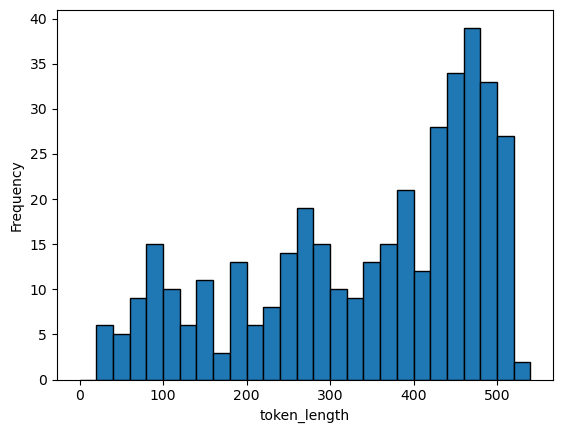

In [43]:
data = pd.DataFrame(p)
import numpy as np

bins = np.arange(0, 550, 20)

data['token_length'].plot(kind='hist', bins=bins, edgecolor='black',xlabel="token_length")



In [44]:
with open('data/processed/chunks/chunks.json', 'w') as f:
    json.dump(docs, f, indent=4)

# Build the Embedding setup

In [45]:
import chromadb

## Creating the persistent database

In [46]:
client  = chromadb.PersistentClient(path = "./data/database/chromadb/")

In [47]:
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction
import torch
try:
    device = "cuda" if torch.cuda.is_available() else 'cpu'
    embedding_fn = SentenceTransformerEmbeddingFunction(model_name='BAAI/bge-base-en-v1.5', device=device)
except Exception as e:
    log.exception(f"An Error occured: {e}")
    raise CustomException(e, sys)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3890.80it/s]
BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [48]:
client.delete_collection(name="mdr")
collection = client.get_or_create_collection(name = "mdr", 
                                     embedding_function=embedding_fn,
                                     configuration={
                                                "hnsw": {
                                                    "space": "cosine",
                                                    "ef_construction": 300
                                                }
                                            })

In [49]:
collection.configuration

{'hnsw': {'space': 'cosine',
  'ef_construction': 300,
  'ef_search': 100,
  'max_neighbors': 16,
  'resize_factor': 1.2,
  'sync_threshold': 1000},
 'spann': None,
 'embedding_function': <chromadb.utils.embedding_functions.sentence_transformer_embedding_function.SentenceTransformerEmbeddingFunction at 0x7557a638eed0>}

### Evaluating Small

* Add few chunks to collection
* Evaluate with a query and check the semantic match
* check what it returns: Distance or similarity?

In [50]:
import hashlib
ids, pcs, metadatas = [],[],[]
for doc in docs:
    metadata = doc.get('metadata')
    metadatas.append(metadata)
    pc = doc.get('page_content')
    pcs.append(pc)
    chunk_id = hashlib.sha256(pc.encode('utf-8')).hexdigest()
    ids.append(chunk_id)
'''
collection.add(ids=ids, 
                   documents=pcs,
                   metadatas=metadatas)
    '''

'\ncollection.add(ids=ids, \n                   documents=pcs,\n                   metadatas=metadatas)\n    '

In [51]:
import hashlib
ids1, pcs, metadatas = [],[],[]
for doc in docs:
    metadata = doc.get('metadata')
    metadatas.append(metadata)
    pc = doc.get('page_content')
    pcs.append(pc)
    chunk_id = hashlib.sha256(pc.encode('utf-8')).hexdigest()
    ids1.append(chunk_id)


    

In [52]:
print(len(ids), len(ids1))
print("identical:", ids == ids1)

383 383
identical: True


In [53]:
len(ids) == len(set(ids))

True

### Confirm the colletion count

In [54]:
collection.count()

0

### Confirm the embedding dimensions

In [55]:
# Pullng one embedding
collection.get(include=['embeddings'], ids=["2fa14721893766c74fe238401df190da4d802fd600f9fccdcda37781ce6143e4"]).get('embeddings').shape

(0,)

### Querying from the added chunks to get the self-match distance

In [56]:
query_1 = collection.query(
    query_texts=["Why did the EU replace the old medical device directives?"],
    n_results=3
)

In [57]:
query_1.get('metadatas')

[[]]

In [58]:
query_1.get('distances')

[[]]

### Querying with negative query(unrelated question)

In [59]:
query_2 = collection.query(
    query_texts=["What are the UDI carrier placement rules for reusable devices?"],
    n_results=3
)

In [60]:
query_2.get('metadatas')

[[]]

In [61]:
query_2.get('distances')

[[]]

## Observations:
1. The collection is persistent and store the chunks efficiently.
2. The Embedding function works well and generates expected embeddings dimensions which is 768.
3. The chromadb's retrieval fetches the semantically matched information and gices efficient distance scores.


## Scalling to all the chunks
* Delete and rebuild the collections

* Build the lists across all the chunks
 
* Assert Uniqueness

* Add all chunks to collection

* Confirm the collection count

### Delete-and-rebuild collection

In [62]:
client.delete_collection(name="mdr")
collection = client.get_or_create_collection(name = "mdr", 
                                     embedding_function=embedding_fn,
                                     configuration={
                                                "hnsw": {
                                                    "space": "cosine",
                                                    "ef_construction": 300
                                                }
                                            })

### Build the lists across all the chunks

In [63]:
len(docs)

383

In [64]:
import hashlib

try:
    ids, metadatas, pcs= [], [], []
    for doc in docs:
        pc = doc.get('page_content')
        pcs.append(pc)
        metadatas.append(doc.get('metadata'))
        ids.append(hashlib.sha256(pc.encode("utf-8")).hexdigest())

except Exception as e:
    log.exception(f"The Error occured: {e, sys}")
    raise CustomException(e,sys)

In [65]:
# Confirm the total docs
len(ids)

383

### Assert Uniqueness

In [66]:
len(ids) == len(set(ids))

True

### Add to collection

In [67]:
if len(ids) == len(set(ids)):
    collection.add(ids=ids, 
                   documents=pcs,
                   metadatas=metadatas)

### Assert the count

In [68]:
collection.count()

383

### Questions:

1. Under what conditions are medical devices manufactured and used within health institutions exempt from the requirements of the regulation? Gold chunk that contains article 5
2. Compare the product categories in Annex XVI that involve modifications to the human body. Which categories involve surgical invasion, injections, electromagnetic radiation, and brain stimulation, and what are their respective purposes?
3. What shall be included by the PMCF plan?
4. What are the requirements mentioned in Article 62 for conformity of devices?
5. How can a manufacturer obtain proof that a CE-marked device can be marketed in the European Union for export purposes?(similar to previous question)
6. what is 'notified body'?
7. What are the differences in conformity assessment between Class IIa and Class IIb devices?
8. What is the definition of a medical device under MDR?
9. Where does the 'Regulation (EU) 2017/745' not apply?
10. which documents are required if one wants to perform clinincal invastigation?

In [69]:
query_3 = collection.query(
    query_texts=["which documents are required if one wants to perform clinincal invastigation?"],
    n_results=5
)

In [70]:
query_3

{'ids': [['c7e0a1cb74f42053dff33a1fe6f853700a1727ef6b6059b7f26353da27a91ed1',
   '1579851598b4acec1dab01d2f5c5cc90ede418476a41c3c66bc28647389520a3',
   '3c1d1bd2069a1c57d27c8dcb661d6d2abc21aef4105285166dc5255477d19f75',
   'd5aefd745e2a8dfa2479f8ad281d966b057451378cdb870c6670dccb71bd6097',
   'b88d53c6bd450b7ea7d572f6201777cfae1452ecff8fd6aa0359e389a038100f']],
 'embeddings': None,
 'documents': [["Chunk_Context: \n4.\nWith regard to documentation other than that referred to in the second subparagraph of paragraph 3, the \n\ncoordinating Member State shall: \n(a)  within six days of receipt of the single application, notify the sponsor that it is the coordinating Member State \n('notification date'); \n(b)  for the purpose of the validation of the application, take into account any considerations submitted within seven \ndays of the notification date by any Member State concerned; \n(c)  within 10 days of the notification date, assess whether the clinical investigation falls within the

In [71]:
eval_questions = ["Under what conditions are medical devices manufactured and used within health institutions exempt from the requirements of the regulation? Gold chunk that contains article 5",
"Compare the product categories in Annex XVI that involve modifications to the human body. Which categories involve surgical invasion, injections, electromagnetic radiation, and brain stimulation, and what are their respective purposes?",
"What shall be included by the PMCF plan?",
"What are the requirements mentioned in Article 62 for conformity of devices?",
"How can a manufacturer obtain proof that a CE-marked device can be marketed in the European Union for export purposes?",
"what is 'notified body'?",
"What are the differences in conformity assessment between Class IIa and Class IIb devices?",
"What is the definition of a medical device under MDR?",
"Where does the 'Regulation (EU) 2017/745' not apply?",
"which documents are required if one wants to perform clinincal invastigation?"]

container = []

for question in eval_questions:
    
    query = collection.query(
    query_texts=[question],
    n_results=5
    )
    
    container.append({"question": question,
        "retrieved_data": query}
                )

with open("data/evaluation/test_questions.json", 'w') as f:
    json.dump(container, f, indent=4)

In [72]:
container

[{'question': 'Under what conditions are medical devices manufactured and used within health institutions exempt from the requirements of the regulation? Gold chunk that contains article 5',
  'retrieved_data': {'ids': [['97b680a9dabccb750917494758b64de41cfe7aa5aa6decb8ae9d04c92a603ec5',
     '162926f667cbc295d58bc67cc68181501f2bcdf578fc2f6a5dd7d4e2aa1f32bd',
     '0118f1c42bc1890f046afdfc8f5379b48276acc8f12e55917477a4498d2b4998',
     '151e26b411b1b68981ce7c18044b5654091b0aec98152b5b3eda26fb3538eeed',
     '9e0cf2fbbe43d58df1fbed76ded946fe527648dd0fd1093fa0599ac8ada9393e']],
   'embeddings': None,
   'documents': [["Chunk_Context: \n5.\nWith the exception of the relevant general safety and performance requirements set out in Annex I, the \n\nrequirements of this Regulation shall not apply to devices, manufactured and used only within health institutions \nestablished in the Union, provided that all of the following conditions are met: \n(a)  the devices are not transferred to another 

## Building Evaluation

In [73]:
def recall_at_k(retrieved_ids, gold_chunk_ids, k):
    rid_set = set(retrieved_ids[:k])
    gid_set = set(gold_chunk_ids)
    if not len(gid_set & rid_set) == 0:
        return 1
    else: return 0

In [74]:
def RR(retrieved_ids, gold_chunk_ids):
    rank=None
    for i, rid in enumerate(retrieved_ids):
        if rid in gold_chunk_ids:
            rank = i+1
            break
    if rank is not None:    
        return 1 / rank

    return 0

In [75]:
from pathlib import Path
evalution_set = Path("data/evaluation/test_questions.json")


with open(evalution_set, 'r') as f:
    eval_data = json.load(f)

hits = 0
reciprocal_ranks = []
for questions in eval_data['questions']:
    question = questions['question']
    results = collection.query(query_texts=[question], n_results=5)
    gold_chunk_id = questions['gold_chunk_ids']
    retrieved_ids = results['ids'][0]
    recall = recall_at_k(retrieved_ids, gold_chunk_id, k=1)
    if recall:
        hits += 1
    reciprocal_ranks.append(RR(retrieved_ids, gold_chunk_id))

   

recall_at_1  = hits/len(eval_data['questions'])
MRR = sum(reciprocal_ranks)/len(eval_data['questions'])


TypeError: list indices must be integers or slices, not str

In [ ]:
recall_at_1, MRR

(0.7, 0.72)

In [76]:
def label(number, title):
    if title:
        return f"{number} ({title})"
    return number

In [ ]:
def create_source(metadata: dict):
    article= metadata.get('article', "").strip()
    annex = metadata.get("annex","").strip()
    chapter = str(metadata.get('chapter',"")).strip()
    chapter_title = metadata.get("chapter_title", "").strip()
    annex_title = metadata.get("annex_title","").strip()
    article_title = metadata.get("article_title", "").strip()
    section = metadata.get("section","").strip()
    section_title = metadata.get("section_title").strip()

    if chapter == "0" and chapter_title == "preamble":
        source = "Source: EU MDR Preamble"
    
    elif article:
        parts = []
        if chapter: parts.append(label(chapter, chapter_title))
        if section: parts.append(label(section,section_title))
        parts.append(label(article, article_title))
        source = "Source: In " + ", ".join(parts)

    elif annex:
        parts = [label(annex, annex_title)]
        if chapter: parts.append(label(chapter, chapter_title))
        source = "Source: In " + ", ".join(parts)

    return source

